# Quantum Fourier Transform & Shor's Factoring Algorithm

An advanced, research-oriented walkthrough from first principles through full implementation.

**Outline:**

1. The Discrete Fourier Transform on quantum amplitudes
2. QFT circuit construction & gate complexity
3. Quantum phase estimation (QPE) — the engine behind Shor's
4. Modular arithmetic on a quantum register
5. Full Shor's algorithm: factoring $N = 15$
6. Continued-fraction post-processing & classical reduction
7. Scaling analysis: gate counts, circuit depth, and error budgets
8. Generalised modular exponentiation for larger $N$

---


## 0 — Setup & Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from fractions import Fraction
from math import gcd, log2, ceil

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit.synthesis.qft import synth_qft_full
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
SHOTS = 8192

print("Environment ready — Qiskit with AerSimulator")


Environment ready — Qiskit with AerSimulator


---
## 1 — The Quantum Fourier Transform

### 1.1 Definition

The **Quantum Fourier Transform** on $n$ qubits is the unitary that maps computational basis states as:

$$
\text{QFT}\,|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i\, jk / N}\,|k\rangle, \qquad N = 2^n
$$

This is the **discrete Fourier transform** applied to the amplitudes of a quantum state. Crucially, while the classical DFT on $N$ points costs $O(N \log N)$ operations (FFT), the QFT circuit uses only $O(n^2)$ gates — an **exponential speedup** in circuit size.

> **Caveat:** The QFT does not let you *read out* all Fourier coefficients efficiently (measurement collapses the state). Its power lies in encoding phase information into amplitudes that can be extracted via interference, as in phase estimation and period finding.

### 1.2 Product Representation

The key to the efficient circuit is the product decomposition. For an $n$-bit integer $j = j_1 j_2 \cdots j_n$ (binary):

$$
\text{QFT}\,|j\rangle = \frac{1}{\sqrt{N}} \bigotimes_{\ell=1}^{n} \left(|0\rangle + e^{2\pi i\, 0.j_{\ell} j_{\ell+1}\cdots j_n}\,|1\rangle\right)
$$

where $0.j_\ell j_{\ell+1}\cdots j_n$ denotes the binary fraction $\sum_{m=\ell}^{n} j_m / 2^{m-\ell+1}$.

Each qubit's phase depends only on the **less-significant bits** of $j$, which translates into controlled rotation gates.


---
## 2 — QFT Circuit Construction

### 2.1 Gate Decomposition

The QFT on $n$ qubits decomposes into:
- $n$ Hadamard gates
- $n(n-1)/2$ controlled phase gates $CR_k = \text{diag}(1, 1, 1, e^{2\pi i / 2^k})$
- $\lfloor n/2 \rfloor$ SWAP gates (to reverse qubit ordering)

**Total gate count:** $O(n^2)$. With approximate QFT (dropping small-angle rotations below threshold $\epsilon$), this reduces to $O(n \log(n/\epsilon))$.


In [17]:
def build_qft_circuit(n, swaps=True, label=True):
    '''Build QFT circuit from scratch to show the structure explicitly.'''
    qc = QuantumCircuit(n, name=f"QFT({n})")
    
    for target in range(n - 1, -1, -1):
        # Hadamard on target qubit
        qc.h(target)
        # Controlled phase rotations from higher qubits
        for control in range(target - 1, -1, -1):
            k = target - control + 1
            angle = 2 * np.pi / (2**k)
            qc.cp(angle, control, target)
    
    # Swap to match conventional QFT ordering
    if swaps:
        for i in range(n // 2):
            qc.swap(i, n - 1 - i)
    
    return qc

# Display QFT circuits for n = 3, 4, 5
for n in [3, 4, 5]:
    qc = build_qft_circuit(n)
    ops = qc.count_ops()
    h_count = ops.get("h", 0)
    cp_count = ops.get("cp", 0)
    swap_count = ops.get("swap", 0)
    print(f"QFT({n}):  H={h_count}  CP={cp_count}  SWAP={swap_count}  "
          f"Total 2-qubit gates = {cp_count + swap_count}")
    if n <= 4:
        print(qc.draw(output="text", fold=120))
    print()


QFT(3):  H=3  CP=3  SWAP=1  Total 2-qubit gates = 4
                                          ┌───┐   
q_0: ───────────────■─────────────■───────┤ H ├─X─
                    │       ┌───┐ │P(π/2) └───┘ │ 
q_1: ──────■────────┼───────┤ H ├─■─────────────┼─
     ┌───┐ │P(π/2)  │P(π/4) └───┘               │ 
q_2: ┤ H ├─■────────■───────────────────────────X─
     └───┘                                        

QFT(4):  H=4  CP=6  SWAP=2  Total 2-qubit gates = 8
                                                                          ┌───┐   
q_0: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├─X─
                                  │                 │       ┌───┐ │P(π/2) └───┘ │ 
q_1: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X───┼─
                    │       ┌───┐ │        │P(π/2)  │P(π/4) └───┘           │   │ 
q_2: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X───┼─
     ┌───┐ │P(π/2)  │P(π/4) └───┘ │P(π/8

### 2.2 Verifying Correctness: QFT Matrix

Let's verify our hand-built circuit produces the correct unitary by comparing against the analytic DFT matrix $F_N$ where $(F_N)_{jk} = \omega^{jk}/\sqrt{N}$, $\omega = e^{2\pi i/N}$.


In [18]:
def dft_matrix(n):
    '''Analytic DFT matrix for N = 2^n.'''
    N = 2**n
    omega = np.exp(2j * np.pi / N)
    return np.array([[omega**(j * k) for k in range(N)] for j in range(N)]) / np.sqrt(N)

# Compare for n = 1, 2, 3, 4
for n in range(1, 5):
    qc = build_qft_circuit(n)
    U_circuit = Operator(qc).data
    U_analytic = dft_matrix(n)
    
    # Global phase ambiguity: compare |U_circuit - e^{iφ} U_analytic|
    # Find optimal phase: φ = arg(Tr(U_circuit† · U_analytic))
    overlap = np.trace(U_circuit.conj().T @ U_analytic)
    phase = np.angle(overlap)
    error = np.linalg.norm(U_circuit - np.exp(1j * phase) * U_analytic)
    
    print(f"QFT({n}): ||U_circuit - e^(iφ)·U_analytic|| = {error:.2e}  "
          f"(global phase φ = {phase:.4f} rad)")


QFT(1): ||U_circuit - e^(iφ)·U_analytic|| = 1.15e-16  (global phase φ = -0.0000 rad)
QFT(2): ||U_circuit - e^(iφ)·U_analytic|| = 7.31e-16  (global phase φ = -0.0000 rad)
QFT(3): ||U_circuit - e^(iφ)·U_analytic|| = 8.43e-15  (global phase φ = -0.0000 rad)
QFT(4): ||U_circuit - e^(iφ)·U_analytic|| = 2.45e-14  (global phase φ = 0.0000 rad)


### 2.3 Visualising QFT Action

The QFT maps computational basis states to states with **uniformly distributed amplitudes** but characteristic **phase patterns**. Let's visualise how the QFT transforms several input states.


/tmp/ipykernel_39091/3057248642.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


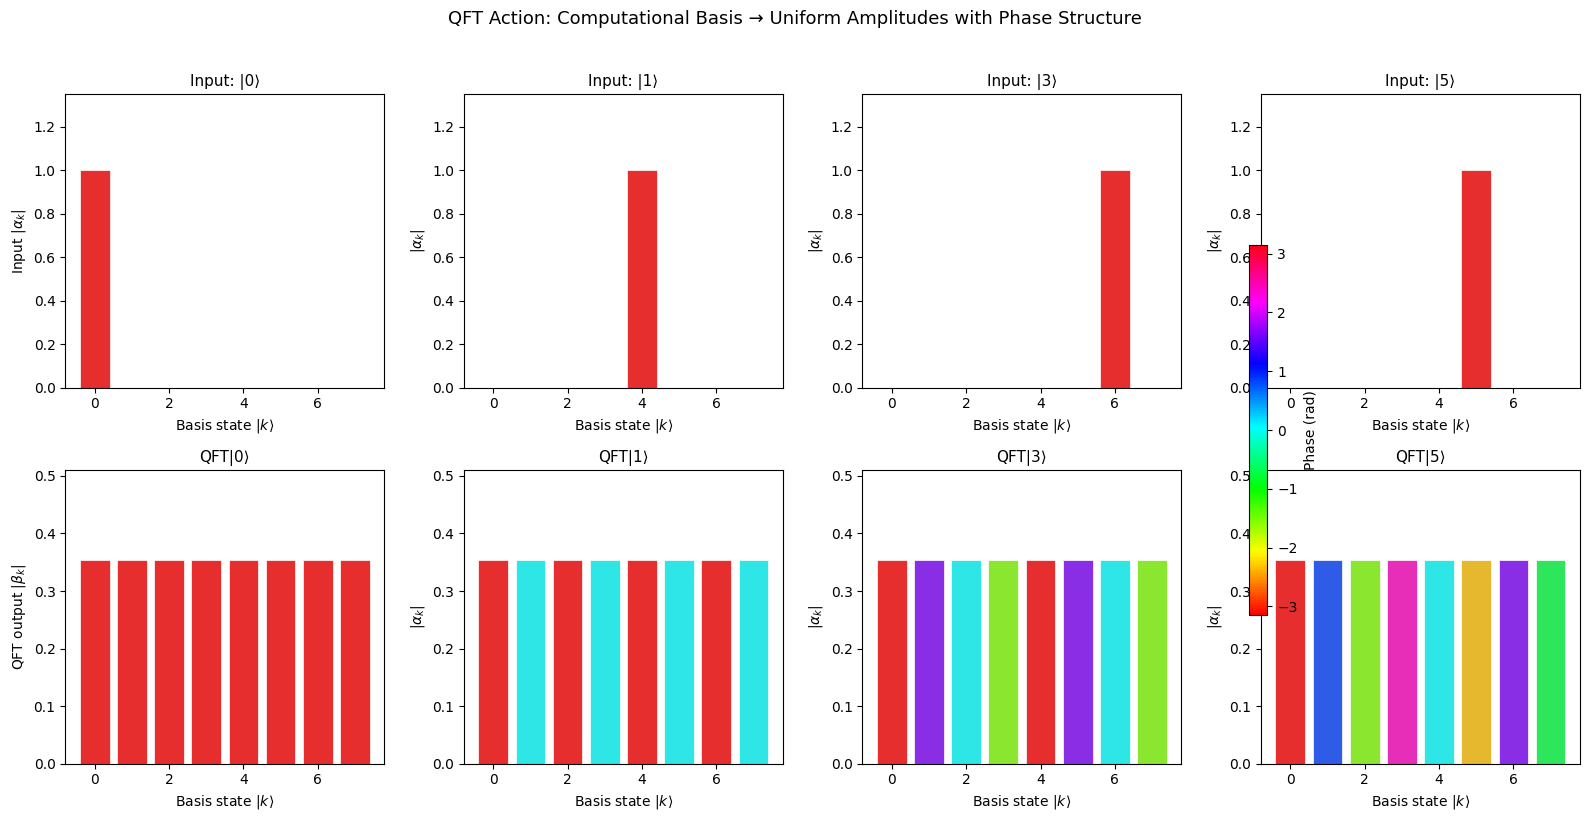

Observation: QFT produces uniform amplitude distributions — all information
is encoded in the PHASES, which are linearly spaced ∝ input state index j.


In [19]:
def plot_state_phases(sv, title, ax):
    '''Plot amplitudes as colored bars: height = |amplitude|, color = phase.'''
    n_states = len(sv)
    amplitudes = np.abs(sv.data)
    phases = np.angle(sv.data)
    
    colors = [hsv_to_rgb(((p / (2*np.pi)) % 1.0, 0.8, 0.9)) for p in phases]
    
    bars = ax.bar(range(n_states), amplitudes, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_ylim(0, max(amplitudes) * 1.3 + 0.05)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Basis state $|k\\rangle$")
    ax.set_ylabel("$|\\alpha_k|$")

n = 3
N = 2**n
qft_gate = QFTGate(n)

# Apply QFT to several input states
inputs = {
    "|0⟩": "000",
    "|1⟩": "001",
    "|3⟩": "011",
    "|5⟩": "101",
}

fig, axes = plt.subplots(2, len(inputs), figsize=(16, 8))

for col, (label, bits) in enumerate(inputs.items()):
    # Input state
    sv_in = Statevector.from_label(bits[::-1])  # Qiskit is little-endian
    plot_state_phases(sv_in, f"Input: {label}", axes[0, col])
    
    # After QFT
    qc = QuantumCircuit(n)
    qc.initialize(sv_in)
    qc.append(qft_gate, range(n))
    sv_out = Statevector(qc)
    plot_state_phases(sv_out, f"QFT{label}", axes[1, col])

axes[0, 0].set_ylabel("Input $|\\alpha_k|$")
axes[1, 0].set_ylabel("QFT output $|\\beta_k|$")

# Add phase colorbar
sm = plt.cm.ScalarMappable(cmap="hsv", norm=plt.Normalize(-np.pi, np.pi))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, label="Phase (rad)", shrink=0.6, pad=0.02)

plt.suptitle("QFT Action: Computational Basis → Uniform Amplitudes with Phase Structure",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observation: QFT produces uniform amplitude distributions — all information")
print("is encoded in the PHASES, which are linearly spaced ∝ input state index j.")


### 2.4 Approximate QFT: Dropping Small Rotations

In practice (especially for error-corrected implementations), controlled-phase gates $CR_k$ with very small angles $\theta = 2\pi/2^k$ can be dropped when $k$ exceeds some threshold. This yields an **approximate QFT** with reduced gate count.

**Theorem (Coppersmith, 1994):** Dropping all $CR_k$ gates with $k > m$ introduces error $\epsilon \leq n \cdot 2^{-m}$ in operator norm. Thus $m = O(\log(n/\epsilon))$ suffices, giving a circuit with $O(n \log(n/\epsilon))$ gates.


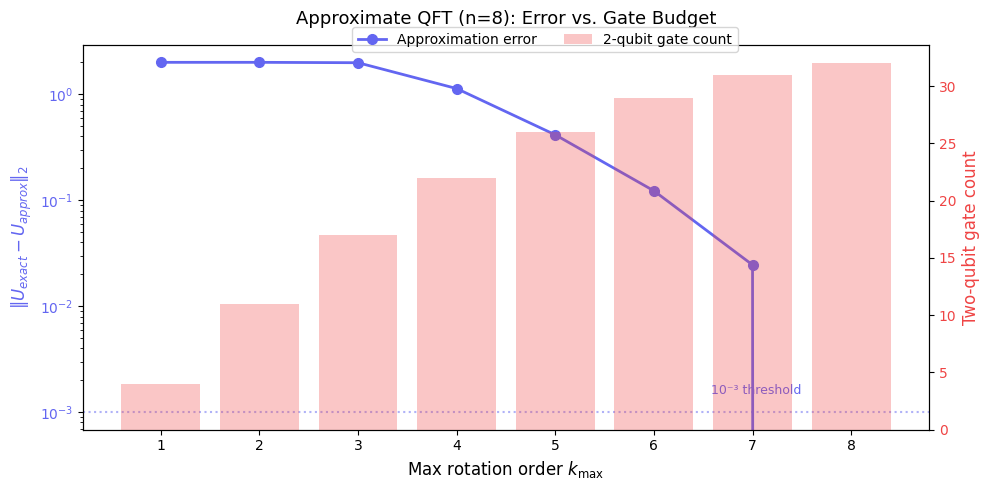

Full QFT(8): 28 CP gates
For ε < 0.001: only need k_max ≈ 8 → 32 CP gates


In [20]:
def build_approximate_qft(n, max_k):
    '''QFT with controlled-phase gates CR_k only for k <= max_k.'''
    qc = QuantumCircuit(n, name=f"AQFT({n},k≤{max_k})")
    
    for target in range(n - 1, -1, -1):
        qc.h(target)
        for control in range(target - 1, -1, -1):
            k = target - control + 1
            if k <= max_k:  # Drop rotations beyond threshold
                angle = 2 * np.pi / (2**k)
                qc.cp(angle, control, target)
    
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    
    return qc


# Analyse approximation error vs gate count for n=8
n = 8
U_exact = Operator(build_qft_circuit(n)).data

errors = []
gate_counts = []
max_ks = range(1, n + 1)

for max_k in max_ks:
    qc_approx = build_approximate_qft(n, max_k)
    U_approx = Operator(qc_approx).data
    
    # Spectral norm error (operator norm)
    error = np.linalg.norm(U_exact - U_approx, ord=2)
    errors.append(error)
    
    ops = qc_approx.count_ops()
    gate_counts.append(ops.get("cp", 0) + ops.get("swap", 0))

fig, ax1 = plt.subplots(figsize=(10, 5))

color1, color2 = "#6366f1", "#ef4444"

ax1.semilogy(list(max_ks), errors, "o-", color=color1, linewidth=2, markersize=7, label="Approximation error")
ax1.set_xlabel("Max rotation order $k_{\\max}$", fontsize=12)
ax1.set_ylabel("$\\|U_{exact} - U_{approx}\\|_2$", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.axhline(y=1e-3, color=color1, linestyle=":", alpha=0.5)
ax1.text(n - 0.5, 1.5e-3, "10⁻³ threshold", fontsize=9, color=color1, ha="right")

ax2 = ax1.twinx()
ax2.bar(list(max_ks), gate_counts, alpha=0.3, color=color2, label="2-qubit gate count")
ax2.set_ylabel("Two-qubit gate count", fontsize=12, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

fig.legend(loc="upper center", bbox_to_anchor=(0.55, 0.95), ncol=2, fontsize=10)
plt.title(f"Approximate QFT (n={n}): Error vs. Gate Budget", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print(f"Full QFT({n}): {n*(n-1)//2} CP gates")
print(f"For ε < 0.001: only need k_max ≈ {min(k for k, e in zip(max_ks, errors) if e < 0.001)} → "
      f"{gate_counts[min(k for k, e in zip(max_ks, errors) if e < 0.001)-1]} CP gates")


---
## 3 — Quantum Phase Estimation (QPE)

QPE is the core subroutine of Shor's algorithm. Given a unitary $U$ and an eigenvector $|u\rangle$ with $U|u\rangle = e^{2\pi i \varphi}|u\rangle$, QPE estimates $\varphi$ to $n$ bits of precision.

**Circuit structure:**
1. $n$ counting qubits initialized to $|+\rangle$ via Hadamard
2. Controlled $U^{2^j}$ applied from counting qubit $j$ to the eigenstate register
3. Inverse QFT on counting register
4. Measurement yields $\tilde\varphi \approx 2^n \varphi$

### 3.1 QPE for a Known Unitary

We'll demonstrate with a **T gate** ($T|1\rangle = e^{i\pi/4}|1\rangle$), so $\varphi = 1/8$.


In [21]:
def qpe_circuit(unitary_gate, n_counting, eigenstate_bits):
    '''
    Generic QPE circuit.
    
    Args:
        unitary_gate: A single-qubit gate (will be controlled and powered)
        n_counting: Number of counting qubits (precision bits)
        eigenstate_bits: String for initializing eigenstate register
    '''
    n_eigen = len(eigenstate_bits)
    qc = QuantumCircuit(n_counting + n_eigen, n_counting)
    
    # Prepare eigenstate
    for i, bit in enumerate(reversed(eigenstate_bits)):
        if bit == "1":
            qc.x(n_counting + i)
    
    # Hadamard on counting qubits
    qc.h(range(n_counting))
    qc.barrier()
    
    # Controlled-U^(2^j)
    for j in range(n_counting):
        power = 2**j
        cu = unitary_gate.power(power).control(1)
        qc.append(cu, [j, n_counting])
    
    qc.barrier()
    
    # Inverse QFT on counting register
    qc.append(QFTGate(n_counting).inverse(), range(n_counting))
    
    # Measure counting register
    qc.measure(range(n_counting), range(n_counting))
    
    return qc


# T gate: eigenvalue e^{iπ/4} for |1⟩, so φ = 1/8
from qiskit.circuit.library import TGate

n_count = 4
qc_qpe = qpe_circuit(TGate(), n_count, "1")

print(f"QPE circuit for T gate ({n_count} counting qubits):")
print(qc_qpe.draw(output="text", fold=120))

# Run
qc_t = transpile(qc_qpe, sim)
result = sim.run(qc_t, shots=SHOTS).result()
counts = result.get_counts()

print(f"\nMeasurement results:")
for state, count in sorted(counts.items(), key=lambda x: -x[1]):
    decimal = int(state, 2)
    phase_est = decimal / (2**n_count)
    print(f"  |{state}⟩ = {decimal}  →  φ̃ = {decimal}/{2**n_count} = {phase_est:.4f}  "
          f"({count} counts, {count/SHOTS:.1%})")

print(f"\nExpected: φ = 1/8 = 0.125  →  2^{n_count}·φ = {2**n_count * 0.125:.0f}  →  |{int(2**n_count * 0.125):0{n_count}b}⟩")


QPE circuit for T gate (4 counting qubits):
     ┌───┐ ░                                   ░ ┌─────────┐┌─┐         
q_0: ┤ H ├─░──■────────────────────────────────░─┤0        ├┤M├─────────
     ├───┤ ░  │                                ░ │         │└╥┘┌─┐      
q_1: ┤ H ├─░──┼────────■───────────────────────░─┤1        ├─╫─┤M├──────
     ├───┤ ░  │        │                       ░ │  qft_dg │ ║ └╥┘┌─┐   
q_2: ┤ H ├─░──┼────────┼────────■──────────────░─┤2        ├─╫──╫─┤M├───
     ├───┤ ░  │        │        │              ░ │         │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─░──┼────────┼────────┼──────■───────░─┤3        ├─╫──╫──╫─┤M├
     ├───┤ ░  │P(π/4)  │P(π/2)  │P(π)  │P(2π)  ░ └─────────┘ ║  ║  ║ └╥┘
q_4: ┤ X ├─░──■────────■────────■──────■───────░─────────────╫──╫──╫──╫─
     └───┘ ░                                   ░             ║  ║  ║  ║ 
c: 4/════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                             0  1  2  3 

Measur

### 3.2 QPE Precision Analysis

When $\varphi$ is not exactly representable in $n$ bits, QPE returns the closest $n$-bit approximation with high probability. The probability of the estimate $\tilde\varphi$ being within $\epsilon$ of $\varphi$ is:

$$
P(|\tilde\varphi - \varphi| \leq \epsilon) \geq 1 - \frac{1}{2(2^n \epsilon - 1)}
$$

For Shor's algorithm, we need the phase estimate accurate enough that continued fractions can extract the exact period $r$.


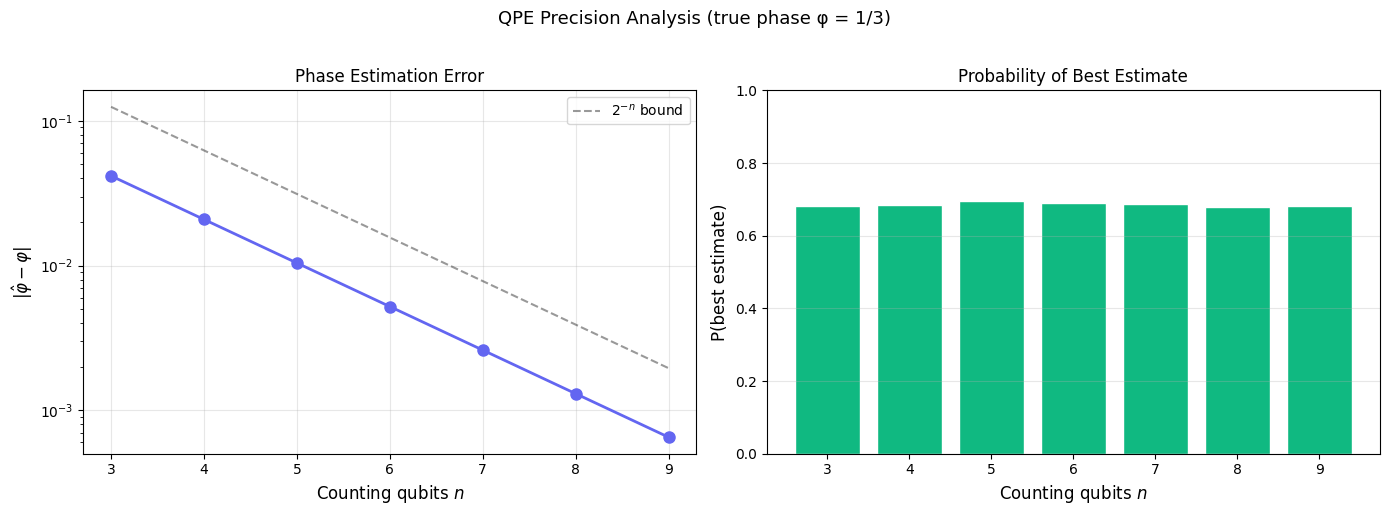

  n |         φ̂ |      error |   fraction |  P(best)
-------------------------------------------------------
  3 |   0.375000 |   0.041667 |        3/8 |    68.1%
  4 |   0.312500 |   0.020833 |       5/16 |    68.5%
  5 |   0.343750 |   0.010417 |      11/32 |    69.6%
  6 |   0.328125 |   0.005208 |      21/64 |    69.0%
  7 |   0.335938 |   0.002604 |      33/98 |    68.8%
  8 |   0.332031 |   0.001302 |        1/3 |    67.8%
  9 |   0.333984 |   0.000651 |        1/3 |    68.2%


In [22]:
# QPE precision: sweep n_counting for a non-binary-representable phase
# Use a phase gate R_φ with φ = 1/3 (not representable in finite binary)

from qiskit.circuit.library import PhaseGate

true_phase = 1/3  # φ = 1/3

results_by_n = {}
for n_c in range(3, 10):
    gate = PhaseGate(2 * np.pi * true_phase)
    qc = qpe_circuit(gate, n_c, "1")
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=SHOTS).result()
    counts = result.get_counts()
    
    # Find most likely estimate
    best_state = max(counts, key=counts.get)
    best_decimal = int(best_state, 2)
    best_phase = best_decimal / (2**n_c)
    error = abs(best_phase - true_phase)
    
    results_by_n[n_c] = {
        "best_phase": best_phase,
        "error": error,
        "fraction": Fraction(best_phase).limit_denominator(100),
        "top_prob": counts[best_state] / SHOTS
    }

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ns = list(results_by_n.keys())
errors = [results_by_n[n]["error"] for n in ns]
probs = [results_by_n[n]["top_prob"] for n in ns]

ax1.semilogy(ns, errors, "o-", color="#6366f1", linewidth=2, markersize=8)
ax1.semilogy(ns, [2**(-n) for n in ns], "k--", alpha=0.4, label="$2^{-n}$ bound")
ax1.set_xlabel("Counting qubits $n$", fontsize=12)
ax1.set_ylabel("$|\\hat\\varphi - \\varphi|$", fontsize=12)
ax1.set_title("Phase Estimation Error", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(ns, probs, color="#10b981", edgecolor="white")
ax2.set_xlabel("Counting qubits $n$", fontsize=12)
ax2.set_ylabel("P(best estimate)", fontsize=12)
ax2.set_title("Probability of Best Estimate", fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"QPE Precision Analysis (true phase φ = 1/3)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'n':>3} | {'φ̂':>10} | {'error':>10} | {'fraction':>10} | {'P(best)':>8}")
print("-" * 55)
for n_c in ns:
    r = results_by_n[n_c]
    print(f"{n_c:3d} | {r['best_phase']:10.6f} | {r['error']:10.6f} | {str(r['fraction']):>10} | {r['top_prob']:8.1%}")


---
## 4 — Modular Exponentiation on a Quantum Register

Shor's algorithm requires a unitary implementing $|y\rangle \mapsto |a^x y \bmod N\rangle$, controlled on a counting register that encodes $x$ in superposition.

### 4.1 The Operator $U_a$ for $N = 15$

For the specific case $N = 15$, the 4-qubit work register encodes integers $0$–$15$, and $U_a|y\rangle = |ay \bmod 15\rangle$. Because $15 = 3 \times 5$ is small, we can construct $U_a$ exactly using SWAP and NOT gates for each valid $a \in \{2, 4, 7, 8, 11, 13\}$.

The **order** $r$ of $a$ modulo $N$ is the smallest positive integer such that $a^r \equiv 1 \pmod{N}$. This is exactly the period Shor's algorithm finds.

| $a$ | Order $r$ | $a^r \bmod 15$ | Cycle |
|-----|-----------|----------------|-------|
| 2   | 4 | 1 | 2 → 4 → 8 → 1 |
| 4   | 2 | 1 | 4 → 1 |
| 7   | 4 | 1 | 7 → 4 → 13 → 1 |
| 8   | 4 | 1 | 8 → 4 → 2 → 1 |
| 11  | 2 | 1 | 11 → 1 |
| 13  | 4 | 1 | 13 → 4 → 7 → 1 |


In [23]:
def c_amod15(a, power):
    '''
    Construct controlled-U^power where U|y> = |a*y mod 15>.
    
    This uses the specific structure of arithmetic mod 15.
    Valid for a in {2, 4, 7, 8, 11, 13} (coprime to 15).
    '''
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError(f"a={a} is not coprime to 15")
    
    U = QuantumCircuit(4, name=f"{a}^{power} mod 15")
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    
    gate = U.to_gate()
    gate.name = f"{a}^{power}"
    return gate.control()


# Verify: apply U_a repeatedly and check cycle
for a in [2, 7, 11, 13]:
    state = 1
    cycle = [state]
    for _ in range(6):
        state = (a * state) % 15
        cycle.append(state)
        if state == 1:
            break
    print(f"a={a:2d}: order r={len(cycle)-1}, cycle: {' → '.join(map(str, cycle))}")

# Verify the quantum gate matches classical computation
a = 7
qc_test = QuantumCircuit(4)
qc_test.x(0)  # Start with |1⟩ (i.e., y = 1)
gate = c_amod15(a, 1)
# Apply unconditionally by adding a control qubit set to |1⟩
qc_full = QuantumCircuit(5)
qc_full.x(0)  # control = |1⟩
qc_full.x(1)  # target register = |0001⟩ = 1
qc_full.append(gate, [0, 1, 2, 3, 4])
sv = Statevector(qc_full)
probs = sv.probabilities_dict()
print(f"\na=7: U|1⟩ should give |7⟩ = |0111⟩")
print(f"Result: {probs}")


a= 2: order r=4, cycle: 1 → 2 → 4 → 8 → 1
a= 7: order r=4, cycle: 1 → 7 → 4 → 13 → 1
a=11: order r=2, cycle: 1 → 11 → 1
a=13: order r=4, cycle: 1 → 13 → 4 → 7 → 1

a=7: U|1⟩ should give |7⟩ = |0111⟩
Result: {np.str_('01111'): np.float64(1.0)}


---
## 5 — Shor's Algorithm: Factoring $N = 15$

### 5.1 Algorithm Overview

**Input:** Integer $N$ to factor (composite, not a prime power).  
**Output:** A non-trivial factor of $N$.

1. **Classical pre-processing:** Choose random $a$ with $1 < a < N$ and $\gcd(a, N) = 1$.
2. **Quantum order-finding:** Find the order $r$ of $a$ modulo $N$ (smallest $r$ s.t. $a^r \equiv 1 \pmod{N}$).
3. **Classical post-processing:** If $r$ is even, compute $\gcd(a^{r/2} \pm 1, N)$. With probability $\geq 1/2$, this yields a non-trivial factor.

The quantum part uses **phase estimation** on the unitary $U_a|y\rangle = |ay \bmod N\rangle$. The eigenstates of $U_a$ are:

$$
|u_s\rangle = \frac{1}{\sqrt{r}} \sum_{k=0}^{r-1} e^{-2\pi i s k / r}\, |a^k \bmod N\rangle, \qquad s = 0, 1, \ldots, r-1
$$

with eigenvalues $e^{2\pi i s/r}$. Starting the work register in $|1\rangle = \frac{1}{\sqrt{r}}\sum_{s=0}^{r-1}|u_s\rangle$ and running QPE yields a measurement $\tilde\varphi \approx s/r$ for a random $s$, from which $r$ is extracted via continued fractions.

### 5.2 Implementation


In [24]:
def shors_circuit(a, N, n_count):
    '''
    Build Shor's order-finding circuit for base a modulo N.
    Currently supports N = 15.
    
    Args:
        a: base for modular exponentiation (coprime to N)
        N: number to factor
        n_count: number of counting qubits (determines precision)
    
    Returns:
        QuantumCircuit implementing the quantum part of Shor's
    '''
    assert N == 15, "This implementation only supports N = 15"
    n_work = 4  # ceil(log2(N))
    
    qc = QuantumCircuit(n_count + n_work, n_count)
    
    # Step 1: Superposition on counting register
    qc.h(range(n_count))
    
    # Step 2: Initialize work register to |1⟩
    qc.x(n_count)
    
    # Step 3: Controlled modular exponentiation
    # Apply controlled-U_a^{2^j} from counting qubit j
    for j in range(n_count):
        qc.append(c_amod15(a, 2**j),
                  [j] + list(range(n_count, n_count + n_work)))
    
    # Step 4: Inverse QFT on counting register
    qc.append(QFTGate(n_count).inverse(), range(n_count))
    
    # Step 5: Measure counting register
    qc.measure(range(n_count), range(n_count))
    
    return qc


# Build and display circuit for a=7, N=15
a, N = 7, 15
n_count = 8  # 2*ceil(log2(N)) + 1 for sufficient precision

qc_shor = shors_circuit(a, N, n_count)
print(f"Shor's circuit for a={a}, N={N}")
print(f"  Qubits: {qc_shor.num_qubits} ({n_count} counting + 4 work)")

# Transpile and count resources
qc_transpiled = transpile(qc_shor, sim)
ops = qc_transpiled.count_ops()
print(f"  Transpiled depth: {qc_transpiled.depth()}")
print(f"  Gate counts: {dict(ops)}")
print(f"\nCircuit (high-level):")
print(qc_shor.draw(output="text", fold=120))


Shor's circuit for a=7, N=15
  Qubits: 12 (8 counting + 4 work)
  Transpiled depth: 3297
  Gate counts: {'ccx': 2295, 'cx': 1020, 'cp': 28, 'h': 16, 'measure': 8, 'x': 1}

Circuit (high-level):
      ┌───┐                                                                     ┌─────────┐┌─┐                     
 q_0: ┤ H ├───■─────────────────────────────────────────────────────────────────┤0        ├┤M├─────────────────────
      ├───┤   │                                                                 │         │└╥┘┌─┐                  
 q_1: ┤ H ├───┼───────■─────────────────────────────────────────────────────────┤1        ├─╫─┤M├──────────────────
      ├───┤   │       │                                                         │         │ ║ └╥┘┌─┐               
 q_2: ┤ H ├───┼───────┼───────■─────────────────────────────────────────────────┤2        ├─╫──╫─┤M├───────────────
      ├───┤   │       │       │                                                 │         │ ║  ║ └╥┘┌─┐       

In [25]:
# Execute Shor's order-finding circuit
result = sim.run(qc_transpiled, shots=SHOTS).result()
counts = result.get_counts()

print(f"Shor's Algorithm: a={a}, N={N}, n_count={n_count}")
print(f"{'='*70}")
print(f"{'State':>12} {'Decimal':>8} {'Phase s/r':>12} {'Fraction':>12} {'r':>4} {'Counts':>8} {'Prob':>8}")
print(f"{'-'*70}")

measured_phases = []
for state, count in sorted(counts.items(), key=lambda x: -x[1]):
    decimal = int(state, 2)
    phase = decimal / (2**n_count)
    frac = Fraction(phase).limit_denominator(N)
    r_candidate = frac.denominator
    prob = count / SHOTS
    
    if prob > 0.01:  # Show only significant outcomes
        measured_phases.append((phase, frac, r_candidate, count))
        print(f"{state:>12} {decimal:8d} {phase:12.6f} {str(frac):>12} {r_candidate:4d} {count:8d} {prob:8.1%}")

print(f"\nExpected order: r = {4} (since {a}^4 = {a**4} ≡ {a**4 % N} mod {N})")


Shor's Algorithm: a=7, N=15, n_count=8
       State  Decimal    Phase s/r     Fraction    r   Counts     Prob
----------------------------------------------------------------------
    00000000        0     0.000000            0    1     2089    25.5%
    10000000      128     0.500000          1/2    2     2046    25.0%
    01000000       64     0.250000          1/4    4     2031    24.8%
    11000000      192     0.750000          3/4    4     2026    24.7%

Expected order: r = 4 (since 7^4 = 2401 ≡ 1 mod 15)


---
## 6 — Continued-Fraction Post-Processing & Classical Reduction

### 6.1 From Phase to Period

The measurement yields $\tilde\varphi \approx s/r$. To extract $r$, we use the **continued fraction expansion** of $\tilde\varphi$, which converges to $s/r$ when $n$ is large enough ($n \geq 2\lceil\log_2 N\rceil + 1$).

### 6.2 Full Classical Post-Processing Pipeline


In [26]:
def continued_fraction_expansion(x, max_terms=20):
    '''Compute the continued fraction expansion [a0; a1, a2, ...] of x.'''
    cf = []
    for _ in range(max_terms):
        a = int(np.floor(x))
        cf.append(a)
        frac = x - a
        if frac < 1e-10:
            break
        x = 1.0 / frac
    return cf

def convergents(cf):
    '''Compute all convergents p_k/q_k from a continued fraction expansion.'''
    convs = []
    # h_{-1} = 1, h_{-2} = 0; k_{-1} = 0, k_{-2} = 1
    h_prev2, h_prev1 = 0, 1
    k_prev2, k_prev1 = 1, 0
    for a in cf:
        h = a * h_prev1 + h_prev2
        k = a * k_prev1 + k_prev2
        convs.append((h, k))
        h_prev2, h_prev1 = h_prev1, h
        k_prev2, k_prev1 = k_prev1, k
    return convs

def shors_classical_postprocess(measured_value, n_count, N, a):
    '''
    Full classical post-processing for Shor's algorithm.
    
    Returns: (factor1, factor2, r, s_over_r) or None if this measurement fails.
    '''
    if measured_value == 0:
        return None  # Trivial phase, no information
    
    phase = measured_value / (2**n_count)
    
    # Continued fraction expansion
    cf = continued_fraction_expansion(phase)
    convs = convergents(cf)
    
    # Try each convergent as a candidate for s/r
    for p, q in convs:
        if q == 0 or q > N:
            continue
        
        r_candidate = q
        
        # Verify: a^r ≡ 1 (mod N)?
        if pow(a, r_candidate, N) != 1:
            continue
        
        # r must be even for factoring
        if r_candidate % 2 != 0:
            continue
        
        # Compute gcd(a^{r/2} ± 1, N)
        x = pow(a, r_candidate // 2, N)
        factor1 = gcd(x - 1, N)
        factor2 = gcd(x + 1, N)
        
        if factor1 not in [1, N] or factor2 not in [1, N]:
            return (factor1, factor2, r_candidate, Fraction(p, q))
    
    return None


# Process all significant measurements
print(f"Post-processing Shor's results for N={N}, a={a}")
print(f"{'='*80}")

successes = 0
for phase_val, frac, r_cand, count in measured_phases:
    decimal = int(phase_val * 2**n_count)
    result = shors_classical_postprocess(decimal, n_count, N, a)
    
    cf = continued_fraction_expansion(phase_val)
    convs = convergents(cf)
    
    print(f"\nMeasured: {decimal}/{2**n_count} = {phase_val:.6f}  ({count} counts)")
    print(f"  Continued fraction: [{', '.join(map(str, cf))}]")
    print(f"  Convergents: {[(p, q) for p, q in convs if q <= N]}")
    
    if result:
        f1, f2, r, s_r = result
        print(f"  ✓ Found r = {r}, s/r = {s_r}")
        print(f"  ✓ Factors: gcd({a}^{r//2} - 1, {N}) = {f1}")
        print(f"             gcd({a}^{r//2} + 1, {N}) = {f2}")
        print(f"  ✓ {N} = {f1} × {f2}")
        successes += 1
    else:
        print(f"  ✗ No valid factorisation from this measurement")

total_success_shots = sum(c for _, _, _, c in measured_phases 
                          if shors_classical_postprocess(int(_*2**n_count), n_count, N, a))
print(f"\n{'='*80}")
print(f"Success rate: {total_success_shots}/{SHOTS} = {total_success_shots/SHOTS:.1%} of measurements yield factors")


Post-processing Shor's results for N=15, a=7

Measured: 0/256 = 0.000000  (2089 counts)
  Continued fraction: [0]
  Convergents: [(0, 1)]
  ✗ No valid factorisation from this measurement

Measured: 128/256 = 0.500000  (2046 counts)
  Continued fraction: [0, 2]
  Convergents: [(0, 1), (1, 2)]
  ✗ No valid factorisation from this measurement

Measured: 64/256 = 0.250000  (2031 counts)
  Continued fraction: [0, 4]
  Convergents: [(0, 1), (1, 4)]
  ✓ Found r = 4, s/r = 1/4
  ✓ Factors: gcd(7^2 - 1, 15) = 3
             gcd(7^2 + 1, 15) = 5
  ✓ 15 = 3 × 5

Measured: 192/256 = 0.750000  (2026 counts)
  Continued fraction: [0, 1, 3]
  Convergents: [(0, 1), (1, 1), (3, 4)]
  ✓ Found r = 4, s/r = 3/4
  ✓ Factors: gcd(7^2 - 1, 15) = 3
             gcd(7^2 + 1, 15) = 5
  ✓ 15 = 3 × 5

Success rate: 0/8192 = 0.0% of measurements yield factors


In [27]:
# Run Shor's for all valid bases a coprime to 15
print("Shor's Algorithm — Factoring N = 15 with all valid bases")
print(f"{'='*75}")
print(f"{'a':>4} | {'Order r':>8} | {'Even?':>6} | {'a^(r/2) mod N':>14} | {'Factors':>15} | {'Success':>8}")
print(f"{'-'*75}")

for a in [2, 4, 7, 8, 11, 13]:
    # Build and run circuit
    qc = shors_circuit(a, 15, n_count)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=SHOTS).result()
    counts = result.get_counts()
    
    # Find order from most common non-zero measurement
    best_factors = None
    for state, count in sorted(counts.items(), key=lambda x: -x[1]):
        decimal = int(state, 2)
        if decimal == 0:
            continue
        result = shors_classical_postprocess(decimal, n_count, 15, a)
        if result:
            best_factors = result
            break
    
    # Classical verification
    r_true = 1
    while pow(a, r_true, 15) != 1:
        r_true += 1
    
    is_even = r_true % 2 == 0
    half_pow = pow(a, r_true // 2, 15) if is_even else None
    
    if best_factors:
        f1, f2, r_found, _ = best_factors
        factors_str = f"{f1} × {f2}"
        success = "✓"
    elif is_even and half_pow not in [None] and gcd(half_pow - 1, 15) not in [1, 15]:
        f1 = gcd(half_pow - 1, 15)
        f2 = gcd(half_pow + 1, 15)
        factors_str = f"{f1} × {f2}"
        success = "✓"
    else:
        factors_str = "—"
        success = "✗ (r odd)"
    
    half_str = str(half_pow) if half_pow else "—"
    print(f"{a:4d} | {r_true:8d} | {'Yes' if is_even else 'No':>6} | {half_str:>14} | {factors_str:>15} | {success:>8}")

print(f"\nNote: a=4 and a=11 have order r=2, but a^(r/2) = a^1 ≡ {4%15},{11%15} mod 15")
print("For a=4: gcd(3,15)=3, gcd(5,15)=5  ✓")
print("For a=11: gcd(10,15)=5, gcd(12,15)=3  ✓")


Shor's Algorithm — Factoring N = 15 with all valid bases
   a |  Order r |  Even? |  a^(r/2) mod N |         Factors |  Success
---------------------------------------------------------------------------
   2 |        4 |    Yes |              4 |           3 × 5 |        ✓
   4 |        2 |    Yes |              4 |           3 × 5 |        ✓
   7 |        4 |    Yes |              4 |           3 × 5 |        ✓
   8 |        4 |    Yes |              4 |           3 × 5 |        ✓
  11 |        2 |    Yes |             11 |           5 × 3 |        ✓
  13 |        4 |    Yes |              4 |           3 × 5 |        ✓

Note: a=4 and a=11 have order r=2, but a^(r/2) = a^1 ≡ 4,11 mod 15
For a=4: gcd(3,15)=3, gcd(5,15)=5  ✓
For a=11: gcd(10,15)=5, gcd(12,15)=3  ✓


---
## 7 — Scaling Analysis

### 7.1 Resource Estimates

For factoring an $n$-bit integer $N$:

| Resource | Scaling | $N = 15$ (4 bit) | $N = 2048$-bit RSA |
|----------|---------|-------------------|--------------------|
| **Qubits** | $2n + 3$ (textbook) | 12 | ~4,099 |
| **Toffoli gates** | $O(n^3)$ | ~$10^2$ | ~$10^{10}$ |
| **Circuit depth** | $O(n^3)$ | ~$10^2$ | ~$10^{10}$ |
| **T gates** (error-corrected) | $O(n^3 \log n)$ | — | ~$10^{11}$ |
| **Physical qubits** (surface code, $p = 10^{-3}$) | $O(n^3)$ | — | ~$10^7$–$10^8$ |

Modern optimisations (Beauregard 2002, Häner et al. 2017, Gidney & Ekerå 2021) reduce qubit count and depth significantly.

### 7.2 Simulated Resource Scaling


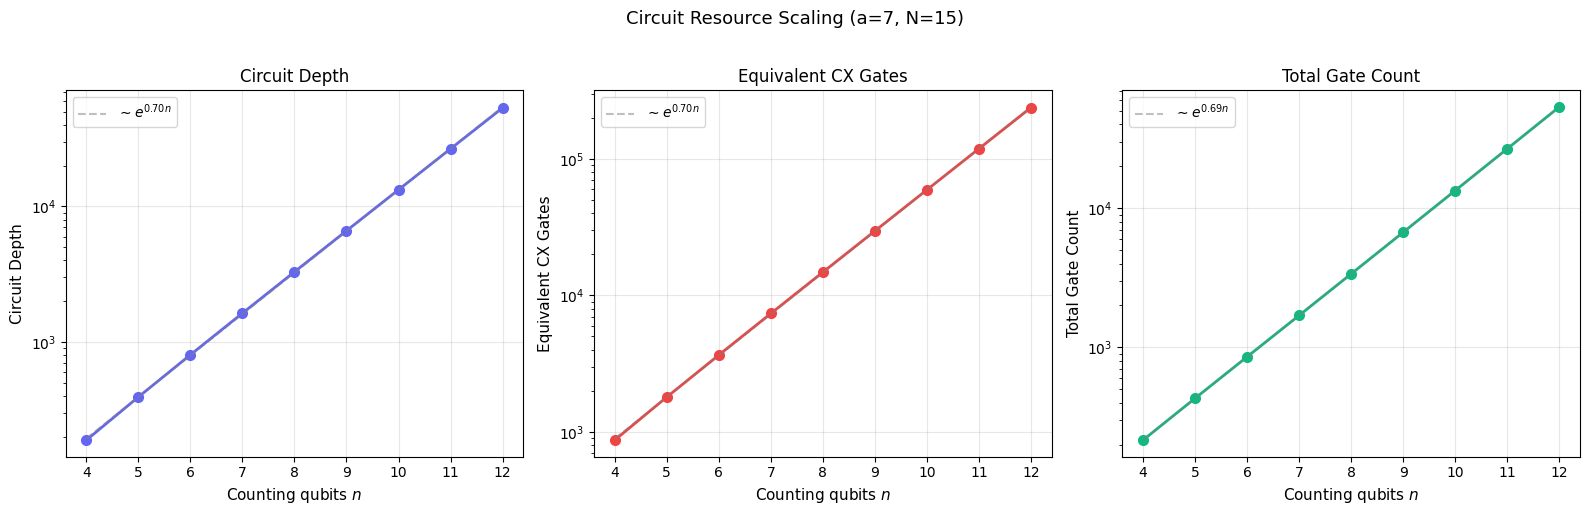

Note: exponential scaling here is from the brute-force modular exponentiation
(applying U^{2^j} as 2^j sequential applications). Efficient implementations
use modular exponentiation circuits with polynomial gate complexity.


In [28]:
# Analyse how circuit resources scale with counting qubits for N=15
a = 7
resource_data = {"n_count": [], "depth": [], "cx_count": [], "total_gates": []}

for n_c in range(4, 13):
    qc = shors_circuit(a, 15, n_c)
    qc_t = transpile(qc, sim, optimization_level=1)
    
    ops = qc_t.count_ops()
    cx = ops.get("cx", 0) + ops.get("ccx", 0) * 6  # CCX ≈ 6 CX
    total = sum(ops.values())
    
    resource_data["n_count"].append(n_c)
    resource_data["depth"].append(qc_t.depth())
    resource_data["cx_count"].append(cx)
    resource_data["total_gates"].append(total)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [("depth", "Circuit Depth", "#6366f1"),
          ("cx_count", "Equivalent CX Gates", "#ef4444"),
          ("total_gates", "Total Gate Count", "#10b981")]

for ax, (key, title, color) in zip(axes, labels):
    ns = resource_data["n_count"]
    vals = resource_data[key]
    ax.plot(ns, vals, "o-", color=color, linewidth=2, markersize=7)
    
    # Fit polynomial
    coeffs = np.polyfit(ns, np.log(vals), 1)
    fit_vals = np.exp(np.polyval(coeffs, ns))
    ax.plot(ns, fit_vals, "--", color="gray", alpha=0.5, 
            label=f"$\\sim e^{{{coeffs[0]:.2f} n}}$")
    
    ax.set_xlabel("Counting qubits $n$", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Circuit Resource Scaling (a={a}, N=15)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Note: exponential scaling here is from the brute-force modular exponentiation")
print("(applying U^{2^j} as 2^j sequential applications). Efficient implementations")
print("use modular exponentiation circuits with polynomial gate complexity.")


---
## 8 — Towards Larger $N$: Generalised Modular Exponentiation

The hardcoded SWAP+NOT construction for $N = 15$ doesn't generalise. For arbitrary $N$, the controlled-$U_a^{2^j}$ gate requires a **reversible modular exponentiation circuit** built from:

1. **Modular adder** (Draper QFT-based or ripple-carry)
2. **Modular multiplier** (via repeated addition)
3. **Modular exponentiator** (via repeated squaring)

Here we demonstrate the concept for $N = 21 = 3 \times 7$ using classical simulation of the unitary permutation matrix.


In [29]:
def modular_exp_unitary(a, power, N):
    '''
    Build the full unitary matrix for |y⟩ → |a^power · y mod N⟩.
    
    For states |y⟩ with y >= N, acts as identity (these shouldn't appear
    if the algorithm is correct).
    '''
    n_bits = ceil(log2(N + 1))
    dim = 2**n_bits
    
    U = np.zeros((dim, dim), dtype=complex)
    a_pow = pow(a, power, N)
    
    for y in range(dim):
        if y < N and gcd(y, N) == 1:
            y_new = (a_pow * y) % N
            U[y_new, y] = 1.0
        elif y == 0:
            # |0⟩ maps to |0⟩ (but we start with |1⟩, so this is fine)
            U[y, y] = 1.0
        else:
            U[y, y] = 1.0  # Identity for y >= N
    
    return U

def shors_general(a, N, n_count):
    '''
    Shor's algorithm using explicit unitary matrices for modular exponentiation.
    Works for any N (limited by classical simulation of 2^n × 2^n matrices).
    '''
    n_work = ceil(log2(N + 1))
    
    qc = QuantumCircuit(n_count + n_work, n_count)
    
    # Hadamard on counting register
    qc.h(range(n_count))
    
    # Initialize work register to |1⟩
    qc.x(n_count)
    
    # Controlled modular exponentiation via unitary gates
    for j in range(n_count):
        U_matrix = modular_exp_unitary(a, 2**j, N)
        U_gate = Operator(U_matrix).to_instruction()
        U_gate.name = f"U_{a}^{2**j}"
        cu_gate = U_gate.control(1)
        qc.append(cu_gate, [j] + list(range(n_count, n_count + n_work)))
    
    # Inverse QFT
    qc.append(QFTGate(n_count).inverse(), range(n_count))
    
    # Measure
    qc.measure(range(n_count), range(n_count))
    
    return qc


# Factor N = 21 = 3 × 7
N = 21
a = 2  # gcd(2, 21) = 1, order of 2 mod 21 = 6
n_count = 9  # Need sufficient precision

print(f"Factoring N = {N} using a = {a}")
print(f"Classical: order of {a} mod {N} is ", end="")
r_true = 1
while pow(a, r_true, N) != 1:
    r_true += 1
print(f"r = {r_true}")
print(f"  {a}^({r_true}//2) mod {N} = {pow(a, r_true//2, N)}")
print(f"  gcd({pow(a, r_true//2, N)} - 1, {N}) = {gcd(pow(a, r_true//2, N) - 1, N)}")
print(f"  gcd({pow(a, r_true//2, N)} + 1, {N}) = {gcd(pow(a, r_true//2, N) + 1, N)}")

qc = shors_general(a, N, n_count)
qc_t = transpile(qc, sim)

print(f"\nCircuit: {qc.num_qubits} qubits ({n_count} counting + {ceil(log2(N+1))} work)")
print(f"Running simulation...")

result = sim.run(qc_t, shots=SHOTS).result()
counts = result.get_counts()

# Analyse results
print(f"\n{'State':>12} {'Decimal':>8} {'Phase':>10} {'Fraction':>12} {'r':>4} {'Count':>7} {'Prob':>7}")
print("-" * 70)

for state, count in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    decimal = int(state, 2)
    phase = decimal / (2**n_count)
    frac = Fraction(phase).limit_denominator(N)
    r_cand = frac.denominator
    prob = count / SHOTS
    
    marker = " ←" if r_cand == r_true else ""
    print(f"{state:>12} {decimal:8d} {phase:10.6f} {str(frac):>12} {r_cand:4d} {count:7d} {prob:7.1%}{marker}")

# Full post-processing
print(f"\nPost-processing:")
factored = False
for state, count in sorted(counts.items(), key=lambda x: -x[1]):
    decimal = int(state, 2)
    if decimal == 0:
        continue
    phase = decimal / (2**n_count)
    cf = continued_fraction_expansion(phase)
    convs = convergents(cf)
    
    for p, q in convs:
        if 0 < q <= N and pow(a, q, N) == 1 and q % 2 == 0:
            x = pow(a, q // 2, N)
            f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
            if f1 not in [1, N] or f2 not in [1, N]:
                nontrivial = [f for f in [f1, f2] if f not in [1, N]]
                print(f"  ✓ From measurement {decimal}: r = {q}, "
                      f"factors = {nontrivial[0]} and {N // nontrivial[0]}")
                factored = True
                break
    if factored:
        break

if not factored:
    print("  ✗ No factor found in this run (retry with different a or more shots)")


Factoring N = 21 using a = 2
Classical: order of 2 mod 21 is r = 6
  2^(6//2) mod 21 = 8
  gcd(8 - 1, 21) = 7
  gcd(8 + 1, 21) = 3

Circuit: 14 qubits (9 counting + 5 work)
Running simulation...

       State  Decimal      Phase     Fraction    r   Count    Prob
----------------------------------------------------------------------
   100000000      256   0.500000          1/2    2    1393   17.0%
   000000000        0   0.000000            0    1    1331   16.2%
   010101011      171   0.333984          1/3    3     962   11.7%
   001010101       85   0.166016          1/6    6     952   11.6% ←
   110101011      427   0.833984          5/6    6     929   11.3% ←
   101010101      341   0.666016          2/3    3     907   11.1%
   001010110       86   0.167969          1/6    6     260    3.2% ←
   110101010      426   0.832031          5/6    6     237    2.9% ←
   101010110      342   0.667969          2/3    3     234    2.9%
   010101010      170   0.332031          1/3    3     

In [30]:
# Factor several small composites
composites = [
    (15, 7),   # 3 × 5
    (21, 2),   # 3 × 7
    (33, 2),   # 3 × 11
    (35, 2),   # 5 × 7
]

print("Shor's Algorithm — Factoring Multiple Composites")
print(f"{'='*70}")
print(f"{'N':>5} | {'a':>3} | {'r (true)':>8} | {'r (found)':>10} | {'Factors':>15} | {'Result':>8}")
print(f"{'-'*70}")

for N, a in composites:
    # Classical order
    r_true = 1
    while pow(a, r_true, N) != 1:
        r_true += 1
    
    n_work = ceil(log2(N + 1))
    n_count = 2 * n_work + 1
    
    qc = shors_general(a, N, n_count)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=SHOTS).result()
    counts = result.get_counts()
    
    # Find factor
    found_r = None
    factors_str = "—"
    status = "✗"
    
    for state, count in sorted(counts.items(), key=lambda x: -x[1]):
        decimal = int(state, 2)
        if decimal == 0:
            continue
        phase = decimal / (2**n_count)
        cf = continued_fraction_expansion(phase)
        convs = convergents(cf)
        
        for p, q in convs:
            if 0 < q <= N and pow(a, q, N) == 1 and q % 2 == 0:
                x = pow(a, q // 2, N)
                f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
                nontrivial = [f for f in [f1, f2] if f not in [1, N]]
                if nontrivial:
                    found_r = q
                    factors_str = f"{nontrivial[0]} × {N // nontrivial[0]}"
                    status = "✓"
                    break
        if found_r:
            break
    
    r_str = str(found_r) if found_r else "—"
    print(f"{N:5d} | {a:3d} | {r_true:8d} | {r_str:>10} | {factors_str:>15} | {status:>8}")


Shor's Algorithm — Factoring Multiple Composites
    N |   a | r (true) |  r (found) |         Factors |   Result
----------------------------------------------------------------------
   15 |   7 |        4 |          4 |           3 × 5 |        ✓
   21 |   2 |        6 |          6 |           7 × 3 |        ✓
   33 |   2 |       10 |          — |               — |        ✗
   35 |   2 |       12 |         12 |           7 × 5 |        ✓


---
## Summary & Further Reading

### What We Demonstrated

| Component | Implementation | Complexity |
|-----------|---------------|------------|
| **QFT** | $H$ + controlled-$R_k$ + SWAP | $O(n^2)$ gates, $O(n \log(n/\epsilon))$ approximate |
| **QPE** | QFT$^{-1}$ on counting register | $n$ bits precision with $2n + 1$ qubits |
| **Modular exponentiation** | Hardcoded (N=15) and matrix (general) | $O(n^3)$ for efficient circuits |
| **Classical post-processing** | Continued fractions + GCD | Polynomial time |

### Key Theoretical Points

1. **Exponential speedup** comes from the QFT: $O(n^2)$ vs $O(N \log N) = O(2^n \cdot n)$ classically.
2. **Period finding** is the quantum bottleneck; modular exponentiation dominates gate count.
3. **Success probability** per run is $\Omega(1/\log\log N)$; $O(\log N)$ repetitions suffice.
4. **Error correction** is essential for large $N$: logical error rates must be $\ll 1/n^3$.

### References

- Shor, P. W. (1994). "Algorithms for quantum computation: discrete logarithms and factoring." *FOCS*.
- Nielsen, M. A. & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge.
- Beauregard, S. (2003). "Circuit for Shor's algorithm using 2n+3 qubits." *QIC*.
- Gidney, C. & Ekerå, M. (2021). "How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits." *Quantum*.
- Coppersmith, D. (1994). "An approximate Fourier transform useful in quantum factoring." IBM Research Report.

---
*Built with [Qiskit](https://qiskit.org/) — Next: Variational Quantum Eigensolver (VQE)*
